In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

In [5]:
data = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Order_raw_data.csv"
df = pd.read_csv(data)


In [15]:
print([col for col in df.columns if 'pay' in col.lower()])
#print(df.columns.unique())

['seller_oms_payment_approved_date_key', 'order_payment_type']



 Top 10 drivers
                       Feature  Driver_impact
0         order_billing_amount  116384.811549
10   order_payment_type_nodata       0.504541
6            city_tier_Unknown       0.105627
3            city_tier_Tier 1B       0.086828
8   order_payment_type_Prepaid       0.051039


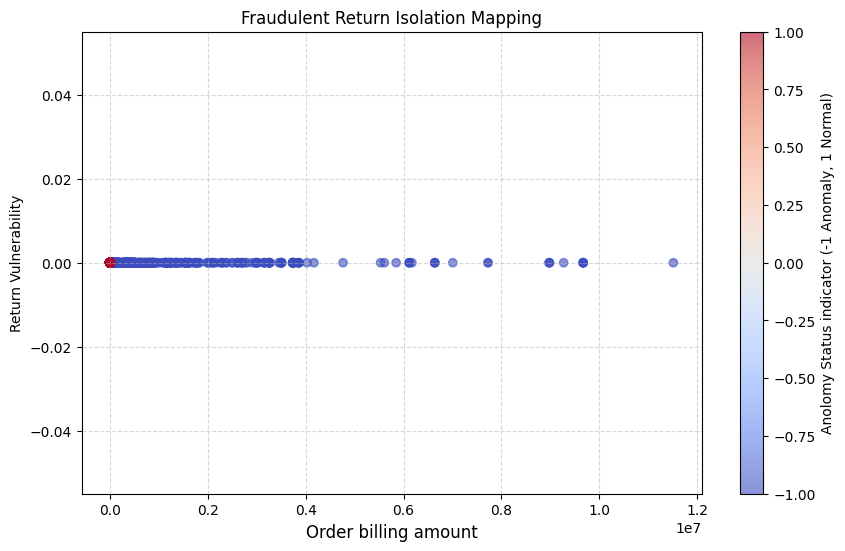

In [18]:
df['return_ratio'] = df['anamoly_adjustment_value'].fillna(0)/(df['order_billing_amount'] +1)
numeric_cols = ["order_billing_amount", "return_ratio"]
categorical_cols = ["city_tier", "order_payment_type"]

for col in categorical_cols:
    df[col] = df[col].replace(['nan', 'Nan', 'NAN'], np.nan)
    df[col] = df[col].fillna("Unknown").astype(str)

X_features = pd.get_dummies(df[numeric_cols + categorical_cols], drop_first =True)
X_features = X_features.fillna(0)

iso_forest = IsolationForest(contamination = 0.02, random_state= 42)
df['anomaly_score'] = iso_forest.fit_predict(X_features)

anomalies =  X_features[df["anomaly_score"] == -1]
normal_data = X_features[df["anomaly_score"] == 1]
driver_scores = (anomalies.mean() - normal_data.mean()).abs()

drivers_df = pd.DataFrame(
    {"Feature":driver_scores.index, 'Driver_impact':driver_scores.values}
).sort_values(by="Driver_impact", ascending=False)

print("\n Top 10 drivers")
print(drivers_df.head())

plt.figure(figsize=(10,6))
plt.scatter(
    df['order_billing_amount'],
    df['return_ratio'],
    c=df['anomaly_score'],
    cmap = 'coolwarm',
    alpha = 0.6
)
plt.title("Fraudulent Return Isolation Mapping")
plt.xlabel("Order billing amount", fontsize=12)
plt.ylabel("Return Vulnerability")
plt.colorbar(label ="Anolomy Status indicator (-1 Anomaly, 1 Normal)")
plt.grid(True, linestyle= "--", alpha=0.5)
plt.show()
